In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import itertools
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

print("✅ All imports successful")

✅ All imports successful


In [13]:
# --------------------------------------------------
# Load data  (adjust paths if needed)
# --------------------------------------------------
train = pd.read_csv('../../../data/rossmann-store-sales/train.csv', low_memory=False, parse_dates=['Date'])
store = pd.read_csv('../../../data/rossmann-store-sales/store.csv')

# Merge store metadata
train = train.merge(store, on='Store', how='left')

# Basic cleaning
train = train[train['Open'] == 1]          # keep only open days
train = train[train['Sales'] > 0]          # remove zero-sales rows
train.sort_values('Date', inplace=True)
train.reset_index(drop=True, inplace=True)


# ── Feature Engineering ──────────────────────────────────────────────────────

# 1. Encode PromoInterval (e.g. "Jan,Apr,Jul,Oct" → numeric)
promo_interval_map = {
    'Jan,Apr,Jul,Oct': 1,
    'Feb,May,Aug,Nov': 2,
    'Mar,Jun,Sept,Dec': 3
}
train['PromoIntervalEncoded'] = train['PromoInterval'].map(promo_interval_map).fillna(0)

# 2. Is the current month inside PromoInterval?
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sept',10:'Oct',11:'Nov',12:'Dec'}
def is_in_promo_interval(row):
    if pd.isna(row['PromoInterval']):
        return 0
    month_str = month_map.get(row['Date'].month, '')
    return 1 if month_str in row['PromoInterval'] else 0

train['InPromoInterval'] = train.apply(is_in_promo_interval, axis=1)

# 3. Days running in Promo2
train['Promo2SinceDate'] = pd.to_datetime(
    train['Promo2SinceYear'].astype(str) + '-W' +
    train['Promo2SinceWeek'].astype(str).str.zfill(2) + '-1',
    format='%Y-W%W-%w', errors='coerce'
)
train['Promo2Duration'] = (train['Date'] - train['Promo2SinceDate']).dt.days.clip(lower=0).fillna(0)

# 4. Competition distance bucketed
train['CompetitionDistance'] = train['CompetitionDistance'].fillna(train['CompetitionDistance'].median())
train['CompDistBucket'] = pd.cut(train['CompetitionDistance'],
                                  bins=[0,500,1000,3000,10000,np.inf],
                                  labels=[0,1,2,3,4]).astype(float)

# 5. StoreType & Assortment encoded
le = LabelEncoder()
train['StoreTypeEnc']  = le.fit_transform(train['StoreType'].fillna('a'))
train['AssortmentEnc'] = le.fit_transform(train['Assortment'].fillna('a'))

# 6. Competition open months
train['CompetitionOpenSinceDate'] = pd.to_datetime(
    dict(year=train['CompetitionOpenSinceYear'],
         month=train['CompetitionOpenSinceMonth'],
         day=1), errors='coerce')
train['CompOpenMonths'] = ((train['Date'] - train['CompetitionOpenSinceDate'])
                            .dt.days / 30).clip(lower=0).fillna(0)

# 7. Day / Week / Month features
train['DayOfWeek']  = train['Date'].dt.dayofweek
train['WeekOfYear'] = train['Date'].dt.isocalendar().week.astype(int)
train['Month']      = train['Date'].dt.month
train['IsWeekend']  = (train['DayOfWeek'] >= 5).astype(int)

print(f"Shape after feature engineering: {train.shape}")
train.head(3)

Shape after feature engineering: (844338, 30)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceDate,Promo2Duration,CompDistBucket,StoreTypeEnc,AssortmentEnc,CompetitionOpenSinceDate,CompOpenMonths,WeekOfYear,Month,IsWeekend
0,1097,1,2013-01-01,5961,1405,1,0,a,1,b,...,NaT,0.0,1.0,1,1,2002-03-01,131.966667,1,1,0
1,85,1,2013-01-01,4220,619,1,0,a,1,b,...,NaT,0.0,2.0,1,0,2011-10-01,15.266667,1,1,0
2,259,1,2013-01-01,6851,1444,1,0,a,1,b,...,NaT,0.0,0.0,1,1,NaT,0.000000,1,1,0


In [14]:
# ══════════════════════════════════════════════════════════════════
#  KAGGLE WINNER FEATURES  — added to the full 'train' dataframe
# ══════════════════════════════════════════════════════════════════

# ── 1. Promo cycle features ───────────────────────────────────────
# Days since the current Promo2 cycle started in that month
# PromoInterval like "Jan,Apr,Jul,Oct" means a new cycle starts each of those months
month_to_num = {'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,
                'Jul':7,'Aug':8,'Sept':9,'Oct':10,'Nov':11,'Dec':12}

def days_in_promo_cycle(row):
    """How many days into the current Promo2 cycle is this row?"""
    if row['Promo2'] == 0 or pd.isna(row['PromoInterval']):
        return 0
    months = [month_to_num.get(m.strip(), 0) for m in row['PromoInterval'].split(',')]
    cur_month = row['Date'].month
    # Find the most recent cycle-start month on or before current month
    past = [m for m in months if m <= cur_month]
    if not past:
        past = months  # wrap around (last cycle started in previous year)
    cycle_start_month = max(past)
    cycle_start = pd.Timestamp(year=row['Date'].year, month=cycle_start_month, day=1)
    return max((row['Date'] - cycle_start).days, 0)

train['DaysInPromoCycle'] = train.apply(days_in_promo_cycle, axis=1)

# Whether today is the FIRST week of a new Promo2 cycle
train['PrimPromoCycle'] = (train['DaysInPromoCycle'] <= 7).astype(int)

# ── 2. Holiday window features ────────────────────────────────────
# For each store/date: were there holidays last week / this week / next week?
train['IsHoliday'] = ((train['StateHoliday'] != '0') | (train['SchoolHoliday'] == 1)).astype(int)

# Sort for rolling
train = train.sort_values(['Store','Date']).reset_index(drop=True)

def holiday_windows(grp):
    grp = grp.sort_values('Date').copy()
    h = grp['IsHoliday']
    # Rolling 7-day windows using date index
    grp['holidays_thisweek'] = h.rolling(7, min_periods=1).sum().values
    grp['holidays_lastweek'] = h.shift(7).rolling(7, min_periods=1).sum().values
    grp['holidays_nextweek'] = h.shift(-7).rolling(7, min_periods=1).sum().values
    return grp

train = train.groupby('Store', group_keys=False).apply(holiday_windows)
train[['holidays_lastweek','holidays_nextweek']] = train[['holidays_lastweek','holidays_nextweek']].fillna(0)

# ── 3. Days since competition opened (unrounded & log-rounded) ────
train['DaysInCompetition'] = ((train['Date'] - train['CompetitionOpenSinceDate'])
                               .dt.days.clip(lower=0).fillna(0))
# Log-rounded version (kaggle winner used this to avoid store-as-proxy leakage)
train['DaysInCompetition_unrounded'] = train['DaysInCompetition']
train['rnd_CompetitionDistance'] = np.round(
    np.log1p(train['CompetitionDistance']), 1
)

# ── 4. Shop-level aggregates (computed across ALL stores, all time) ───
#    These capture each store's "personality"
shop_agg = train.groupby('Store').agg(
    shopavg_open             = ('Open',       'mean'),
    shopavg_salespercustomer = ('Sales',      lambda x: (x / train.loc[x.index,'Customers'].replace(0,np.nan)).mean()),
    shopavg_schoolholiday    = ('SchoolHoliday','mean'),
    shopsales_holiday        = ('Sales',      lambda x: x[train.loc[x.index,'IsHoliday']==1].mean()),
    shopsales_promo          = ('Sales',      lambda x: x[train.loc[x.index,'Promo']==1].mean()),
    shopsales_saturday       = ('Sales',      lambda x: x[train.loc[x.index,'DayOfWeek']==5].mean()),
).reset_index()
shop_agg = shop_agg.fillna(0)
train = train.merge(shop_agg, on='Store', how='left')

# ── 5. Day-level aggregates (avg across all stores for that calendar day) ─
day_agg = train.groupby('Date').agg(
    dayavg_openyesterday = ('Open', 'mean')   # proxy: were stores open yesterday on avg?
).reset_index()
day_agg['dayavg_openyesterday'] = day_agg['dayavg_openyesterday'].shift(1).fillna(0)
train = train.merge(day_agg, on='Date', how='left')

# ── 6. Lag / rolling stats from previous periods ─────────────────
#    prevyear_* : same day last year stats (by store)
#    prevquarter_* : last quarter stats (by store)
#    prevhalfyear_* : last 6 months stats (by store)
train = train.sort_values(['Store','Date']).reset_index(drop=True)

def add_lag_features(grp):
    grp = grp.sort_values('Date').copy()
    s = grp.set_index('Date')['Sales']

    # ── Previous year (same day ± 3 days window, rolling 7d)
    s_shifted_1y = s.shift(365)
    grp['prevyear_med']   = s_shifted_1y.rolling(7, min_periods=1).median().values
    grp['prevyear_m1']    = s_shifted_1y.rolling(7, min_periods=1).mean().values
    grp['prevyear_m2']    = s_shifted_1y.rolling(7, min_periods=1).std().values
    grp['prevyear_p10']   = s_shifted_1y.rolling(7, min_periods=1).quantile(0.1).values

    # ── Previous year by day+promo (approximated as promo-split mean)
    grp['prevyear_dps_med'] = s_shifted_1y.rolling(14, min_periods=1).median().values

    # ── Previous quarter (rolling 90 days, shifted 90)
    s_shifted_q = s.shift(90)
    grp['prevquarter_med'] = s_shifted_q.rolling(90, min_periods=7).median().values
    grp['prevquarter_m1']  = s_shifted_q.rolling(90, min_periods=7).mean().values

    # ── Previous half year
    s_shifted_hy = s.shift(180)
    grp['prevhalfyear']    = s_shifted_hy.rolling(180, min_periods=14).mean().values
    grp['prevhalfyear_m1'] = s_shifted_hy.rolling(90,  min_periods=7).mean().values

    return grp

train = train.groupby('Store', group_keys=False).apply(add_lag_features)

# Fill any remaining NaNs in new lag columns with 0
lag_cols = ['prevyear_med','prevyear_m1','prevyear_m2','prevyear_p10',
            'prevyear_dps_med','prevquarter_med','prevquarter_m1',
            'prevhalfyear','prevhalfyear_m1']
train[lag_cols] = train[lag_cols].fillna(0)

# ── 7. Linear model trend features ───────────────────────────────
# Per-store linear trend fitted on quarterly and yearly windows
def add_linmod_features(grp):
    grp = grp.sort_values('Date').copy()
    grp['t'] = (grp['Date'] - grp['Date'].min()).dt.days
    # Quarterly linear trend: fit on last 90 days, predict next day
    linmod_q = []
    linmod_y = []
    for i in range(len(grp)):
        # quarterly
        window = grp.iloc[max(0, i-90):i]
        if len(window) >= 10:
            coeffs = np.polyfit(window['t'], window['Sales'], 1)
            linmod_q.append(np.polyval(coeffs, grp['t'].iloc[i]))
        else:
            linmod_q.append(grp['Sales'].iloc[i] if i == 0 else linmod_q[-1])
        # yearly
        window_y = grp.iloc[max(0, i-365):i]
        if len(window_y) >= 30:
            coeffs_y = np.polyfit(window_y['t'], window_y['Sales'], 1)
            linmod_y.append(np.polyval(coeffs_y, grp['t'].iloc[i]))
        else:
            linmod_y.append(grp['Sales'].iloc[i] if i == 0 else linmod_y[-1])
    grp['linmod_quarterly'] = linmod_q
    grp['linmod_yearly']    = linmod_y
    return grp

# NOTE: linmod is slow; run on the single store only (applied later in cell 3B)
# For full dataset it would take too long — we compute it per-store in cell 3B

print(f"✅ Kaggle winner features added.  New shape: {train.shape}")
print("New columns added:", [c for c in train.columns if c not in [
    'Store','DayOfWeek','Date','Sales','Customers','Open','Promo',
    'StateHoliday','SchoolHoliday','StoreType','Assortment',
    'CompetitionDistance','CompetitionOpenSinceMonth','CompetitionOpenSinceYear',
    'Promo2','Promo2SinceWeek','Promo2SinceYear','PromoInterval',
    'PromoIntervalEncoded','InPromoInterval','Promo2SinceDate','Promo2Duration',
    'CompDistBucket','StoreTypeEnc','AssortmentEnc','CompetitionOpenSinceDate',
    'CompOpenMonths','DayOfWeek','WeekOfYear','Month','IsWeekend'
]])

✅ Kaggle winner features added.  New shape: (844338, 55)
New columns added: ['DaysInPromoCycle', 'PrimPromoCycle', 'IsHoliday', 'holidays_thisweek', 'holidays_lastweek', 'holidays_nextweek', 'DaysInCompetition', 'DaysInCompetition_unrounded', 'rnd_CompetitionDistance', 'shopavg_open', 'shopavg_salespercustomer', 'shopavg_schoolholiday', 'shopsales_holiday', 'shopsales_promo', 'shopsales_saturday', 'dayavg_openyesterday', 'prevyear_med', 'prevyear_m1', 'prevyear_m2', 'prevyear_p10', 'prevyear_dps_med', 'prevquarter_med', 'prevquarter_m1', 'prevhalfyear', 'prevhalfyear_m1']


In [15]:
# ══════════════════════════════════════════════════════════════════
#  CELL 3B — Build prophet_df for Store 1 with all winner features
# ══════════════════════════════════════════════════════════════════
STORE_ID = 1

df = train[train['Store'] == STORE_ID].copy()
df['StateHoliday'] = (df['StateHoliday'] != '0').astype(int)

# Compute linmod features on this single store (fast)
df = df.sort_values('Date').reset_index(drop=True)
df['t'] = (df['Date'] - df['Date'].min()).dt.days
linmod_q, linmod_y = [], []
for i in range(len(df)):
    window   = df.iloc[max(0, i-90):i]
    window_y = df.iloc[max(0, i-365):i]
    if len(window) >= 10:
        c = np.polyfit(window['t'], window['Sales'], 1)
        linmod_q.append(np.polyval(c, df['t'].iloc[i]))
    else:
        linmod_q.append(df['Sales'].iloc[i] if i == 0 else linmod_q[-1])
    if len(window_y) >= 30:
        c = np.polyfit(window_y['t'], window_y['Sales'], 1)
        linmod_y.append(np.polyval(c, df['t'].iloc[i]))
    else:
        linmod_y.append(df['Sales'].iloc[i] if i == 0 else linmod_y[-1])
df['linmod_quarterly'] = linmod_q
df['linmod_yearly']    = linmod_y

# ── Full regressor list (Prophet will use a subset; XGBoost uses all) ──────
REGRESSORS_PROPHET = [
    # Original
    'Promo', 'Promo2', 'SchoolHoliday', 'StateHoliday', 'IsWeekend',
    'InPromoInterval', 'Promo2Duration',
    'CompDistBucket', 'StoreTypeEnc', 'AssortmentEnc', 'CompOpenMonths',
    # Kaggle winner additions
    'DaysInPromoCycle', 'PrimPromoCycle',
    'holidays_thisweek', 'holidays_lastweek', 'holidays_nextweek',
    'DaysInCompetition_unrounded', 'rnd_CompetitionDistance',
    'shopavg_open', 'shopavg_salespercustomer', 'shopavg_schoolholiday',
    'shopsales_promo', 'shopsales_saturday',
    'dayavg_openyesterday',
    'prevyear_med', 'prevyear_m1', 'prevyear_dps_med',
    'prevquarter_med', 'prevquarter_m1',
    'prevhalfyear', 'prevhalfyear_m1',
]

ALL_FEATURES_XGB = REGRESSORS_PROPHET + [
    # Extra temporal features for XGBoost
    'DayOfWeek', 'WeekOfYear', 'Month',
    'Promo2SinceWeek', 'Promo2SinceYear',
    'CompetitionDistance',
    'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear',
    'linmod_quarterly', 'linmod_yearly',
    'prevyear_m2', 'prevyear_p10',
    'shopsales_holiday',
]

# Build prophet_df
prophet_df = df[['Date','Sales'] + REGRESSORS_PROPHET].copy()
prophet_df.rename(columns={'Date':'ds','Sales':'y'}, inplace=True)
prophet_df.sort_values('ds', inplace=True)
prophet_df.reset_index(drop=True, inplace=True)
for col in REGRESSORS_PROPHET:
    prophet_df[col] = prophet_df[col].fillna(0)

# Build xgb_df (keep Date for splitting)
xgb_df = df[['Date','Sales'] + ALL_FEATURES_XGB].copy()
xgb_df.sort_values('Date', inplace=True)
xgb_df.reset_index(drop=True, inplace=True)
for col in ALL_FEATURES_XGB:
    xgb_df[col] = xgb_df[col].fillna(0)

print(f"prophet_df : {prophet_df.shape}  |  {len(REGRESSORS_PROPHET)} regressors")
print(f"xgb_df     : {xgb_df.shape}  |  {len(ALL_FEATURES_XGB)} features")
prophet_df.head(3)

prophet_df : (781, 33)  |  31 regressors
xgb_df     : (781, 46)  |  44 features


,ds,y,Promo,Promo2,SchoolHoliday,StateHoliday,IsWeekend,InPromoInterval,Promo2Duration,CompDistBucket,...,shopsales_promo,shopsales_saturday,dayavg_openyesterday,prevyear_med,prevyear_m1,prevyear_dps_med,prevquarter_med,prevquarter_m1,prevhalfyear,prevhalfyear_m1
0,2013-01-02,5530,0,0,1,0,0,0,0.0,2.0,...,5300.111429,4942.970149,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2013-01-03,4327,0,0,1,0,0,0,0.0,2.0,...,5300.111429,4942.970149,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2013-01-04,4486,0,0,1,0,0,0,0.0,2.0,...,5300.111429,4942.970149,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
from prophet.make_holidays import make_holidays_df

# Built-in German holidays via Prophet
german_holidays = make_holidays_df(year_list=list(range(2013, 2016)), country='DE')

# Add Rossmann-specific "StateHoliday" events from the data itself
state_hol_dates = prophet_df[prophet_df['StateHoliday'] == 1]['ds']
custom_holidays = pd.DataFrame({
    'holiday'   : 'state_holiday',
    'ds'        : state_hol_dates,
    'lower_window': -1,
    'upper_window':  1,
})

all_holidays = pd.concat([german_holidays, custom_holidays]).drop_duplicates('ds')
print(f"Total holiday rows: {len(all_holidays)}")
all_holidays.head(6)

Total holiday rows: 27


,ds,holiday,lower_window,upper_window
0,2013-01-01,New Year's Day,NaN,NaN
1,2013-03-29,Good Friday,NaN,NaN
2,2013-04-01,Easter Monday,NaN,NaN
3,2013-05-01,Labor Day,NaN,NaN
4,2013-05-09,Ascension Day,NaN,NaN
5,2013-05-20,Whit Monday,NaN,NaN


In [20]:
def evaluate(actual, predicted):
    actual    = np.array(actual)
    predicted = np.array(predicted)
    mask      = actual > 0
    mae   = mean_absolute_error(actual, predicted)
    rmse  = np.sqrt(mean_squared_error(actual, predicted))
    mape  = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100
    rmspe = np.sqrt(np.mean(((actual[mask] - predicted[mask]) / actual[mask]) ** 2)) * 100
    return {'MAE': round(mae,2), 'RMSE': round(rmse,2), 'MAPE%': round(mape,2), 'RMSPE%': round(rmspe,2)}

In [21]:
VALIDATION_WEEKS = 6

split_date = prophet_df['ds'].max() - pd.Timedelta(weeks=VALIDATION_WEEKS)
train_df   = prophet_df[prophet_df['ds'] <= split_date].copy()
val_df     = prophet_df[prophet_df['ds'] >  split_date].copy()

print(f"Train : {len(train_df)} rows  |  {train_df['ds'].min()} → {train_df['ds'].max()}")
print(f"Val   : {len(val_df)}  rows  |  {val_df['ds'].min()}  → {val_df['ds'].max()}")

Train : 745 rows  |  2013-01-02 00:00:00 → 2015-06-19 00:00:00
Val   : 36  rows  |  2015-06-20 00:00:00  → 2015-07-31 00:00:00


In [22]:
# ══════════════════════════════════════════════════════════════════
#  XGBoost train/val split  (same 6-week holdout as Prophet)
# ══════════════════════════════════════════════════════════════════
xgb_split_date = xgb_df['Date'].max() - pd.Timedelta(weeks=6)

xgb_train = xgb_df[xgb_df['Date'] <= xgb_split_date].copy()
xgb_val   = xgb_df[xgb_df['Date'] >  xgb_split_date].copy()

X_train = xgb_train[ALL_FEATURES_XGB]
y_train = xgb_train['Sales']
X_val   = xgb_val[ALL_FEATURES_XGB]
y_val   = xgb_val['Sales']

print(f"XGB Train: {X_train.shape}  |  XGB Val: {X_val.shape}")

XGB Train: (745, 44)  |  XGB Val: (36, 44)


In [23]:
import xgboost as xgb

# ── Optuna objective for XGBoost ──────────────────────────────────
def xgb_objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 200, 1500),
        'max_depth'         : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'gamma'             : trial.suggest_float('gamma', 0, 5),
        'random_state'      : 42,
        'tree_method'       : 'hist',
        'verbosity'         : 0,
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)
    preds   = model.predict(X_val)
    metrics = evaluate(y_val.values, preds)
    return metrics['MAPE%']

XGB_TRIALS = 60
xgb_study  = optuna.create_study(direction='minimize')
xgb_study.optimize(xgb_objective, n_trials=XGB_TRIALS, show_progress_bar=True)

print(f"\n✅ XGBoost Optuna done!  Best MAPE: {xgb_study.best_value:.2f}%")
print("Best XGBoost params:")
for k, v in xgb_study.best_params.items():
    print(f"  {k:25s} = {v}")

  0%|          | 0/60 [00:00<?, ?it/s]


✅ XGBoost Optuna done!  Best MAPE: 6.26%
Best XGBoost params:
  n_estimators              = 979
  max_depth                 = 7
  learning_rate             = 0.03043466596357512
  subsample                 = 0.557115173992336
  colsample_bytree          = 0.8986260392151414
  min_child_weight          = 9
  reg_alpha                 = 0.0031260767068027216
  reg_lambda                = 1.8928195934964545
  gamma                     = 3.677107096941225


XGBoost Validation Metrics:
  MAE        = 272.47
  RMSE       = 359.0
  MAPE%      = 6.26
  RMSPE%     = 8.18


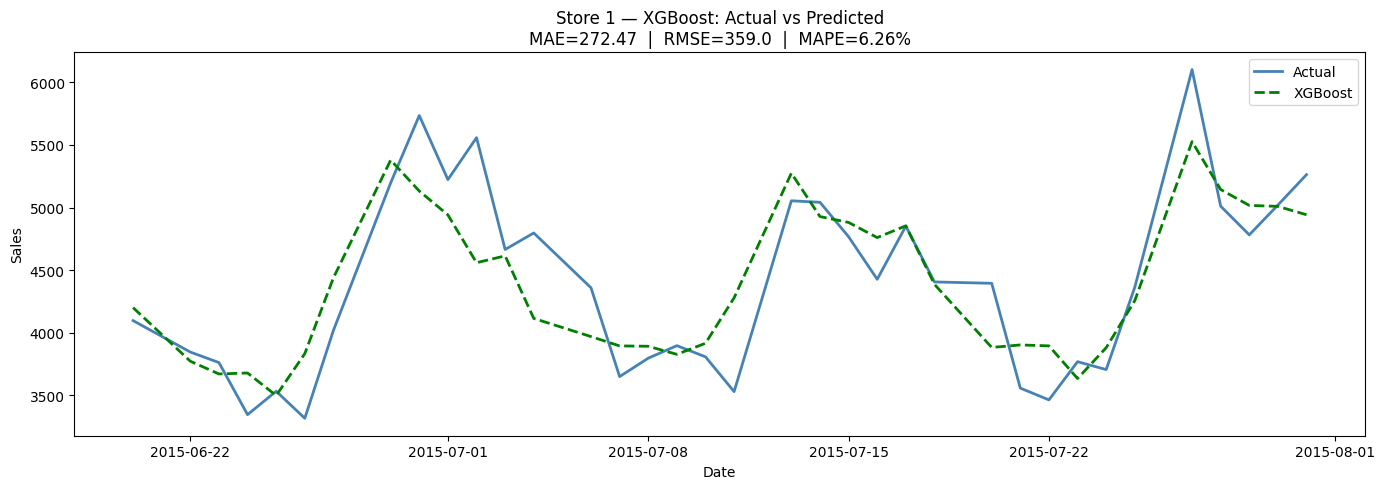

In [24]:
# ── Train final XGBoost on best params ───────────────────────────
best_xgb_params = xgb_study.best_params.copy()
best_xgb_params.update({'random_state': 42, 'tree_method': 'hist', 'verbosity': 0})

best_xgb = xgb.XGBRegressor(**best_xgb_params)
best_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

xgb_preds   = best_xgb.predict(X_val)
xgb_metrics = evaluate(y_val.values, xgb_preds)

print("XGBoost Validation Metrics:")
for k, v in xgb_metrics.items():
    print(f"  {k:10s} = {v}")

# ── Actual vs Predicted plot ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(xgb_val['Date'], y_val.values,  label='Actual',    color='steelblue', linewidth=2)
ax.plot(xgb_val['Date'], xgb_preds,     label='XGBoost',   color='green', linestyle='--', linewidth=2)
ax.set_title(f"Store {STORE_ID} — XGBoost: Actual vs Predicted\n"
             f"MAE={xgb_metrics['MAE']}  |  RMSE={xgb_metrics['RMSE']}  |  MAPE={xgb_metrics['MAPE%']}%")
ax.set_xlabel('Date'); ax.set_ylabel('Sales')
ax.legend(); plt.tight_layout(); plt.show()

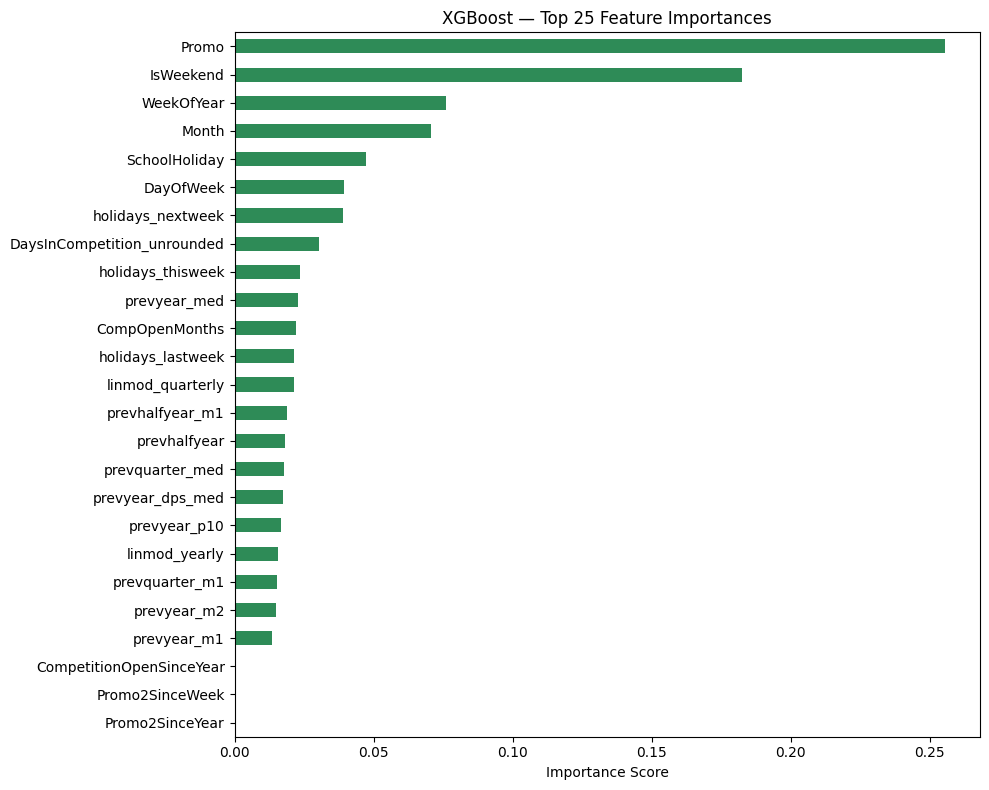


Top 10 most important features:
Promo                          0.255352
IsWeekend                      0.182616
WeekOfYear                     0.076106
Month                          0.070681
SchoolHoliday                  0.047349
DayOfWeek                      0.039523
holidays_nextweek              0.038887
DaysInCompetition_unrounded    0.030383
holidays_thisweek              0.023454
prevyear_med                   0.022826


In [25]:
# ── Feature importance plot ───────────────────────────────────────
importances = pd.Series(best_xgb.feature_importances_, index=ALL_FEATURES_XGB)
importances = importances.sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 8))
importances.sort_values().plot(kind='barh', ax=ax, color='seagreen')
ax.set_title('XGBoost — Top 25 Feature Importances')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(importances.head(10).to_string())

In [26]:
# ── Walk-forward cross validation for XGBoost ─────────────────────
# Mirrors Prophet's CV: train on expanding window, test on next 42 days
from sklearn.model_selection import TimeSeriesSplit

xgb_cv_results = []
dates = xgb_df['Date'].values

# Manual walk-forward: start with 365 days, expand by 90 days each fold
initial_days = 365
period_days  = 90
horizon_days = 42

cutoffs = []
cutoff = xgb_df['Date'].min() + pd.Timedelta(days=initial_days)
while cutoff + pd.Timedelta(days=horizon_days) <= xgb_df['Date'].max():
    cutoffs.append(cutoff)
    cutoff += pd.Timedelta(days=period_days)

print(f"Running {len(cutoffs)} CV folds...")

for cutoff in cutoffs:
    tr = xgb_df[xgb_df['Date'] <= cutoff]
    va = xgb_df[(xgb_df['Date'] > cutoff) &
                (xgb_df['Date'] <= cutoff + pd.Timedelta(days=horizon_days))]
    if len(va) == 0:
        continue

    m = xgb.XGBRegressor(**best_xgb_params)
    m.fit(tr[ALL_FEATURES_XGB], tr['Sales'], verbose=False)
    preds = m.predict(va[ALL_FEATURES_XGB])

    metrics = evaluate(va['Sales'].values, preds)
    metrics['cutoff']  = cutoff
    metrics['horizon'] = len(va)
    xgb_cv_results.append(metrics)

xgb_cv_df = pd.DataFrame(xgb_cv_results)
print("\nXGBoost Walk-Forward CV Results:")
print(xgb_cv_df[['cutoff','horizon','MAE','RMSE','MAPE%']].to_string(index=False))
print(f"\nMean MAPE across folds: {xgb_cv_df['MAPE%'].mean():.2f}%")
print(f"Std  MAPE across folds: {xgb_cv_df['MAPE%'].std():.2f}%")

Running 6 CV folds...

XGBoost Walk-Forward CV Results:
    cutoff  horizon     MAE    RMSE  MAPE%
2014-01-02       36 1239.75 1304.01  28.70
2014-04-02       33  541.95  723.55  10.27
2014-07-01       36  369.90  471.83   8.30
2014-09-29       35  399.40  574.97   8.21
2014-12-28       35  613.40  803.75  13.96
2015-03-28       33  574.32  709.01  11.96

Mean MAPE across folds: 13.57%
Std  MAPE across folds: 7.73%


In [27]:
def build_and_evaluate(params, train_data, val_data, holidays, regressors, verbose=False):
    """
    Builds a Prophet model with the given params dict, fits on train_data,
    and returns (metrics_dict, forecast_df).
    """
    m = Prophet(
        changepoint_prior_scale   = params['changepoint_prior_scale'],
        seasonality_prior_scale   = params['seasonality_prior_scale'],
        holidays_prior_scale      = params['holidays_prior_scale'],
        seasonality_mode          = params['seasonality_mode'],
        changepoint_range         = params['changepoint_range'],
        yearly_seasonality        = params['yearly_seasonality'],
        weekly_seasonality        = params['weekly_seasonality'],
        daily_seasonality         = False,
        holidays                  = holidays,
        interval_width            = 0.95,
    )

    # Custom Fourier seasonalities
    if params.get('add_monthly'):
        m.add_seasonality(name='monthly', period=30.5,
                          fourier_order=params['monthly_fourier_order'])
    if params.get('add_quarterly'):
        m.add_seasonality(name='quarterly', period=91.25,
                          fourier_order=params['quarterly_fourier_order'])

    # Regressors
    selected = params.get('regressors', regressors)
    for reg in selected:
        m.add_regressor(reg)

    m.fit(train_data)

    # Forecast
    future   = m.make_future_dataframe(periods=len(val_data))
    # Fill regressor values for future dates
    future   = future.merge(
        pd.concat([train_data, val_data])[['ds'] + selected],
        on='ds', how='left'
    )
    future[selected] = future[selected].fillna(0)

    forecast = m.predict(future)
    pred_val = forecast[forecast['ds'].isin(val_data['ds'])][['ds','yhat','yhat_lower','yhat_upper']]
    merged   = val_data[['ds','y']].merge(pred_val, on='ds')

    metrics = evaluate(merged['y'].values, merged['yhat'].values)
    if verbose:
        print(f"  → MAE={metrics['MAE']}  RMSE={metrics['RMSE']}  MAPE={metrics['MAPE%']}%  RMSPE={metrics['RMSPE%']}%")

    return metrics, forecast, m

In [28]:
import random

random.seed(42)
np.random.seed(42)

# ── Parameter Grid ─────────────────────────────────────────────────────────
param_grid = {
    'changepoint_prior_scale' : [0.01, 0.05, 0.1, 0.3, 0.5],
    'seasonality_prior_scale' : [0.1, 1.0, 5.0, 10.0],
    'holidays_prior_scale'    : [1.0, 5.0, 10.0],
    'seasonality_mode'        : ['additive', 'multiplicative'],
    'changepoint_range'       : [0.8, 0.9],
    'yearly_seasonality'      : [5, 10, 20],
    'weekly_seasonality'      : [3, 7],
    'add_monthly'             : [True, False],
    'monthly_fourier_order'   : [3, 5],
    'add_quarterly'           : [True, False],
    'quarterly_fourier_order' : [3, 5],
}

REGRESSOR_SUBSETS = {
    'all'          : REGRESSORS,
    'promo_only'   : ['Promo', 'Promo2', 'InPromoInterval', 'Promo2Duration'],
    'core'         : ['Promo', 'SchoolHoliday', 'StateHoliday', 'IsWeekend'],
    'no_regressors': [],
}

# ── Build full combo list & random sample ──────────────────────────────────
keys   = list(param_grid.keys())
combos = list(itertools.product(*param_grid.values()))

N_SAMPLES       = 100   # per regressor set  →  100 × 4 = 400 total
sampled_combos  = random.sample(combos, min(N_SAMPLES, len(combos)))

total = N_SAMPLES * len(REGRESSOR_SUBSETS)
print(f"Full grid size : {len(combos) * len(REGRESSOR_SUBSETS):,}")
print(f"Evaluating     : {total}  (random sample, seed=42)")

# ── Run ────────────────────────────────────────────────────────────────────
results = []
count   = 0

for reg_name, reg_list in REGRESSOR_SUBSETS.items():
    for combo in sampled_combos:
        params = dict(zip(keys, combo))
        params['regressors'] = reg_list

        try:
            metrics, _, _ = build_and_evaluate(
                params, train_df, val_df, all_holidays, reg_list
            )
            metrics['regressor_set'] = reg_name
            metrics.update({k: v for k, v in params.items() if k != 'regressors'})
            results.append(metrics)
        except Exception:
            pass

        count += 1
        if count % 50 == 0:
            best_so_far = min(r['MAPE%'] for r in results) if results else 999
            print(f"  [{count}/{total}]  best MAPE so far: {best_so_far:.2f}%")

results_df = pd.DataFrame(results).sort_values('MAPE%').reset_index(drop=True)
print(f"\n✅ Done!  Best MAPE: {results_df['MAPE%'].iloc[0]:.2f}%")
results_df.head(10)

Full grid size : 92,160
Evaluating     : 400  (random sample, seed=42)


12:21:40 - cmdstanpy - INFO - Chain [1] start processing
12:21:41 - cmdstanpy - INFO - Chain [1] done processing
12:21:41 - cmdstanpy - INFO - Chain [1] start processing
12:21:42 - cmdstanpy - INFO - Chain [1] done processing
12:21:42 - cmdstanpy - INFO - Chain [1] start processing
12:21:42 - cmdstanpy - INFO - Chain [1] done processing
12:21:43 - cmdstanpy - INFO - Chain [1] start processing
12:21:43 - cmdstanpy - INFO - Chain [1] done processing
12:21:44 - cmdstanpy - INFO - Chain [1] start processing
12:21:44 - cmdstanpy - INFO - Chain [1] done processing
12:21:44 - cmdstanpy - INFO - Chain [1] start processing
12:21:44 - cmdstanpy - INFO - Chain [1] done processing
12:21:45 - cmdstanpy - INFO - Chain [1] start processing
12:21:45 - cmdstanpy - INFO - Chain [1] done processing
12:21:46 - cmdstanpy - INFO - Chain [1] start processing
12:21:46 - cmdstanpy - INFO - Chain [1] done processing
12:21:46 - cmdstanpy - INFO - Chain [1] start processing
12:21:47 - cmdstanpy - INFO - Chain [1]

  [50/400]  best MAPE so far: 5.86%


12:22:25 - cmdstanpy - INFO - Chain [1] done processing
12:22:25 - cmdstanpy - INFO - Chain [1] start processing
12:22:25 - cmdstanpy - INFO - Chain [1] done processing
12:22:26 - cmdstanpy - INFO - Chain [1] start processing
12:22:26 - cmdstanpy - INFO - Chain [1] done processing
12:22:26 - cmdstanpy - INFO - Chain [1] start processing
12:22:27 - cmdstanpy - INFO - Chain [1] done processing
12:22:27 - cmdstanpy - INFO - Chain [1] start processing
12:22:27 - cmdstanpy - INFO - Chain [1] done processing
12:22:28 - cmdstanpy - INFO - Chain [1] start processing
12:22:28 - cmdstanpy - INFO - Chain [1] done processing
12:22:28 - cmdstanpy - INFO - Chain [1] start processing
12:22:29 - cmdstanpy - INFO - Chain [1] done processing
12:22:30 - cmdstanpy - INFO - Chain [1] start processing
12:22:31 - cmdstanpy - INFO - Chain [1] done processing
12:22:31 - cmdstanpy - INFO - Chain [1] start processing
12:22:31 - cmdstanpy - INFO - Chain [1] done processing
12:22:32 - cmdstanpy - INFO - Chain [1] 

  [100/400]  best MAPE so far: 5.86%


...

12:25:37 - cmdstanpy - INFO - Chain [1] done processing
12:25:37 - cmdstanpy - INFO - Chain [1] start processing
12:25:37 - cmdstanpy - INFO - Chain [1] done processing
12:25:38 - cmdstanpy - INFO - Chain [1] start processing
12:25:38 - cmdstanpy - INFO - Chain [1] done processing
12:25:38 - cmdstanpy - INFO - Chain [1] start processing
12:25:38 - cmdstanpy - INFO - Chain [1] done processing
12:25:39 - cmdstanpy - INFO - Chain [1] start processing
12:25:39 - cmdstanpy - INFO - Chain [1] done processing
12:25:39 - cmdstanpy - INFO - Chain [1] start processing
12:25:39 - cmdstanpy - INFO - Chain [1] done processing
12:25:40 - cmdstanpy - INFO - Chain [1] start processing
12:25:40 - cmdstanpy - INFO - Chain [1] done processing
12:25:41 - cmdstanpy - INFO - Chain [1] start processing
12:25:41 - cmdstanpy - INFO - Chain [1] done processing
12:25:41 - cmdstanpy - INFO - Chain [1] start processing
12:25:42 - cmdstanpy - INFO - Chain [1] done processing
12:25:43 - cmdstanpy - INFO - Chain [1] 

  [350/400]  best MAPE so far: 5.56%


12:26:08 - cmdstanpy - INFO - Chain [1] start processing
12:26:08 - cmdstanpy - INFO - Chain [1] done processing
12:26:09 - cmdstanpy - INFO - Chain [1] start processing
12:26:09 - cmdstanpy - INFO - Chain [1] done processing
12:26:10 - cmdstanpy - INFO - Chain [1] start processing
12:26:10 - cmdstanpy - INFO - Chain [1] done processing
12:26:10 - cmdstanpy - INFO - Chain [1] start processing
12:26:10 - cmdstanpy - INFO - Chain [1] done processing
12:26:11 - cmdstanpy - INFO - Chain [1] start processing
12:26:11 - cmdstanpy - INFO - Chain [1] done processing
12:26:11 - cmdstanpy - INFO - Chain [1] start processing
12:26:11 - cmdstanpy - INFO - Chain [1] done processing
12:26:12 - cmdstanpy - INFO - Chain [1] start processing
12:26:12 - cmdstanpy - INFO - Chain [1] done processing
12:26:12 - cmdstanpy - INFO - Chain [1] start processing
12:26:12 - cmdstanpy - INFO - Chain [1] done processing
12:26:13 - cmdstanpy - INFO - Chain [1] start processing
12:26:13 - cmdstanpy - INFO - Chain [1]

  [400/400]  best MAPE so far: 5.56%

✅ Done!  Best MAPE: 5.56%


,MAE,RMSE,MAPE%,RMSPE%,regressor_set,changepoint_prior_scale,seasonality_prior_scale,holidays_prior_scale,seasonality_mode,changepoint_range,yearly_seasonality,weekly_seasonality,add_monthly,monthly_fourier_order,add_quarterly,quarterly_fourier_order
0,237.67,326.43,5.56,7.79,promo_only,0.01,5.0,1.0,multiplicative,0.8,20,7,True,5,False,3
1,239.11,325.60,5.60,7.74,promo_only,0.01,5.0,10.0,multiplicative,0.8,20,7,True,5,True,5
2,238.91,325.55,5.60,7.77,promo_only,0.01,1.0,10.0,multiplicative,0.9,20,3,True,5,False,5
3,240.61,326.86,5.70,7.92,promo_only,0.01,5.0,1.0,multiplicative,0.9,5,7,True,5,False,3
4,247.67,334.22,5.77,7.82,core,0.10,1.0,5.0,multiplicative,0.8,20,7,True,5,True,5
5,246.56,331.54,5.83,7.88,promo_only,0.01,0.1,10.0,multiplicative,0.8,20,7,True,3,True,5
6,251.91,340.18,5.86,7.96,all,0.10,1.0,5.0,multiplicative,0.8,20,7,True,5,True,5
7,248.08,335.68,5.88,8.22,promo_only,0.10,0.1,5.0,additive,0.8,5,3,True,5,False,3
8,252.68,355.80,5.89,8.40,promo_only,0.01,5.0,5.0,multiplicative,0.9,20,7,False,5,False,3
9,252.91,356.06,5.90,8.41,promo_only,0.01,5.0,10.0,multiplicative,0.8,20,7,False,5,False,3


In [29]:
# ── Optuna refines the search in far fewer trials ──────────────────────────
def optuna_objective(trial):
    params = {
        'changepoint_prior_scale' : trial.suggest_float('changepoint_prior_scale', 0.001, 1.0, log=True),
        'seasonality_prior_scale' : trial.suggest_float('seasonality_prior_scale', 0.01, 50.0, log=True),
        'holidays_prior_scale'    : trial.suggest_float('holidays_prior_scale', 0.01, 20.0, log=True),
        'seasonality_mode'        : trial.suggest_categorical('seasonality_mode', ['additive','multiplicative']),
        'changepoint_range'       : trial.suggest_float('changepoint_range', 0.7, 0.95),
        'yearly_seasonality'      : trial.suggest_int('yearly_seasonality', 3, 25),
        'weekly_seasonality'      : trial.suggest_int('weekly_seasonality', 3, 10),
        'add_monthly'             : trial.suggest_categorical('add_monthly', [True, False]),
        'monthly_fourier_order'   : trial.suggest_int('monthly_fourier_order', 2, 8),
        'add_quarterly'           : trial.suggest_categorical('add_quarterly', [True, False]),
        'quarterly_fourier_order' : trial.suggest_int('quarterly_fourier_order', 2, 8),
        'regressors'              : REGRESSORS,
    }
    try:
        metrics, _, _ = build_and_evaluate(params, train_df, val_df, all_holidays, REGRESSORS)
        return metrics['MAPE%']
    except:
        return 999.0

N_TRIALS = 60   # increase for better results (slower)
study    = optuna.create_study(direction='minimize')
study.optimize(optuna_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n✅ Optuna done!  Best MAPE: {study.best_value:.2f}%")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k:35s} = {v}")

  0%|          | 0/60 [00:00<?, ?it/s]

12:27:46 - cmdstanpy - INFO - Chain [1] start processing
12:27:47 - cmdstanpy - INFO - Chain [1] done processing
12:27:47 - cmdstanpy - INFO - Chain [1] start processing
12:27:47 - cmdstanpy - INFO - Chain [1] done processing
12:27:48 - cmdstanpy - INFO - Chain [1] start processing
12:27:48 - cmdstanpy - INFO - Chain [1] done processing
12:27:48 - cmdstanpy - INFO - Chain [1] start processing
12:27:49 - cmdstanpy - INFO - Chain [1] done processing
12:27:49 - cmdstanpy - INFO - Chain [1] start processing
12:27:50 - cmdstanpy - INFO - Chain [1] done processing
12:27:50 - cmdstanpy - INFO - Chain [1] start processing
12:27:51 - cmdstanpy - INFO - Chain [1] done processing
12:27:51 - cmdstanpy - INFO - Chain [1] start processing
12:27:51 - cmdstanpy - INFO - Chain [1] done processing
12:27:52 - cmdstanpy - INFO - Chain [1] start processing
12:27:52 - cmdstanpy - INFO - Chain [1] done processing
12:27:53 - cmdstanpy - INFO - Chain [1] start processing
12:27:53 - cmdstanpy - INFO - Chain [1]


✅ Optuna done!  Best MAPE: 5.36%
Best params:
  changepoint_prior_scale             = 0.0013859633306681088
  seasonality_prior_scale             = 0.3637812274355575
  holidays_prior_scale                = 0.1880808019162299
  seasonality_mode                    = multiplicative
  changepoint_range                   = 0.945186478217238
  yearly_seasonality                  = 3
  weekly_seasonality                  = 5
  add_monthly                         = True
  monthly_fourier_order               = 6
  add_quarterly                       = False
  quarterly_fourier_order             = 5


In [ ]:
# ── Combine grid-search best + Optuna best ─────────────────────────────────
best_grid   = results_df.iloc[0].to_dict()
best_optuna = study.best_params.copy()
best_optuna['regressors'] = REGRESSORS

# Rebuild best Optuna model
_, forecast_optuna, best_model = build_and_evaluate(
    best_optuna, train_df, val_df, all_holidays, REGRESSORS, verbose=True
)

# ── Prophet built-in time-series cross-validation ─────────────────────────
print("\nRunning Prophet cross-validation (this takes a few minutes)...")

df_cv = cross_validation(
    best_model,
    initial  = '365 days',   # train on at least 1 year
    period   = '90 days',    # retrain every 90 days
    horizon  = '42 days',    # forecast 6 weeks ahead
    parallel = None
)

df_perf = performance_metrics(df_cv)
print("\nCross-validation performance metrics:")
print(df_perf[['horizon','mae','rmse','mape']].to_string(index=False))

12:28:33 - cmdstanpy - INFO - Chain [1] start processing
12:28:33 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  → MAE=228.45  RMSE=313.86  MAPE=5.36%  RMSPE=7.43%

Running Prophet cross-validation (this takes a few minutes)...


  0%|          | 0/6 [00:00<?, ?it/s]

12:28:33 - cmdstanpy - INFO - Chain [1] start processing
12:28:33 - cmdstanpy - INFO - Chain [1] done processing
12:28:33 - cmdstanpy - INFO - Chain [1] start processing
12:28:34 - cmdstanpy - INFO - Chain [1] done processing
12:28:34 - cmdstanpy - INFO - Chain [1] start processing
12:28:34 - cmdstanpy - INFO - Chain [1] done processing
12:28:34 - cmdstanpy - INFO - Chain [1] start processing
12:28:34 - cmdstanpy - INFO - Chain [1] done processing
12:28:34 - cmdstanpy - INFO - Chain [1] start processing
12:28:34 - cmdstanpy - INFO - Chain [1] done processing
12:28:35 - cmdstanpy - INFO - Chain [1] start processing
12:28:35 - cmdstanpy - INFO - Chain [1] done processing



Cross-validation performance metrics:
horizon        mae        rmse     mape
 4 days 445.274061  522.599252 0.112714
 5 days 479.452801  541.223806 0.118720
 6 days 494.425498  575.021970 0.117373
 7 days 491.752548  561.990267 0.110345
 8 days 472.940585  564.732658 0.103683
 9 days 463.203031  565.490505 0.101553
10 days 392.366502  479.418864 0.087727
11 days 386.449048  481.993629 0.088301
12 days 365.570710  440.818892 0.084123
13 days 417.945693  496.338659 0.095743
14 days 388.441100  482.866212 0.090300
15 days 400.725929  506.221779 0.092195
16 days 411.435303  518.778610 0.091772
17 days 461.450594  565.168102 0.099194
18 days 534.635768  626.360551 0.112396
19 days 675.748077  774.763734 0.136416
20 days 819.475892  909.030962 0.159466
21 days 808.361895  906.454736 0.154508
22 days 800.264043  910.294003 0.146622
23 days 722.321307  825.728550 0.130475
24 days 510.675920  605.386545 0.092294
25 days 505.412889  619.380824 0.087668
26 days 514.087414  619.572343 0.097639
2

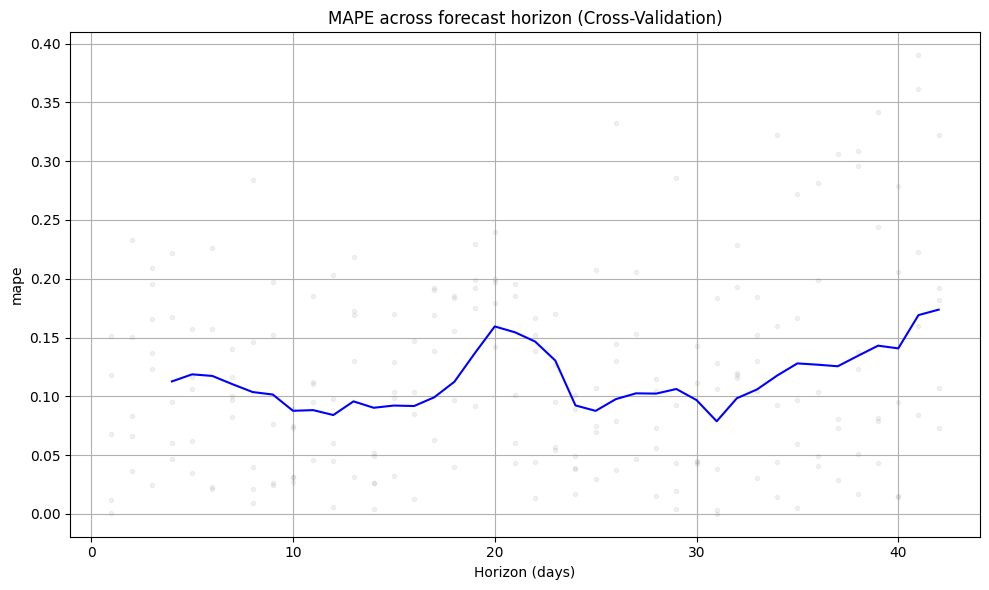

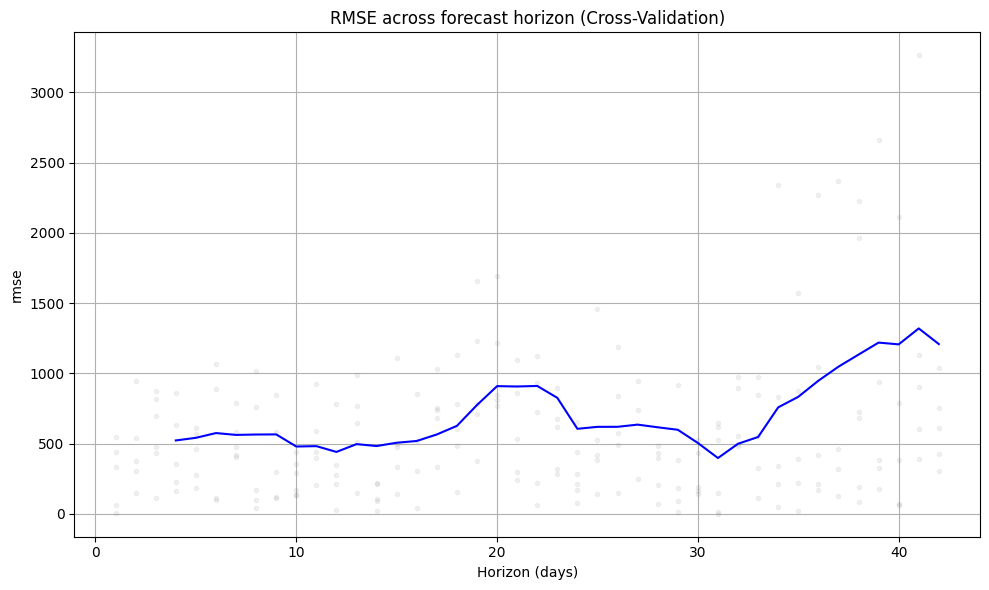

In [31]:
fig = plot_cross_validation_metric(df_cv, metric='mape')
plt.title('MAPE across forecast horizon (Cross-Validation)')
plt.tight_layout()
plt.show()

fig = plot_cross_validation_metric(df_cv, metric='rmse')
plt.title('RMSE across forecast horizon (Cross-Validation)')
plt.tight_layout()
plt.show()

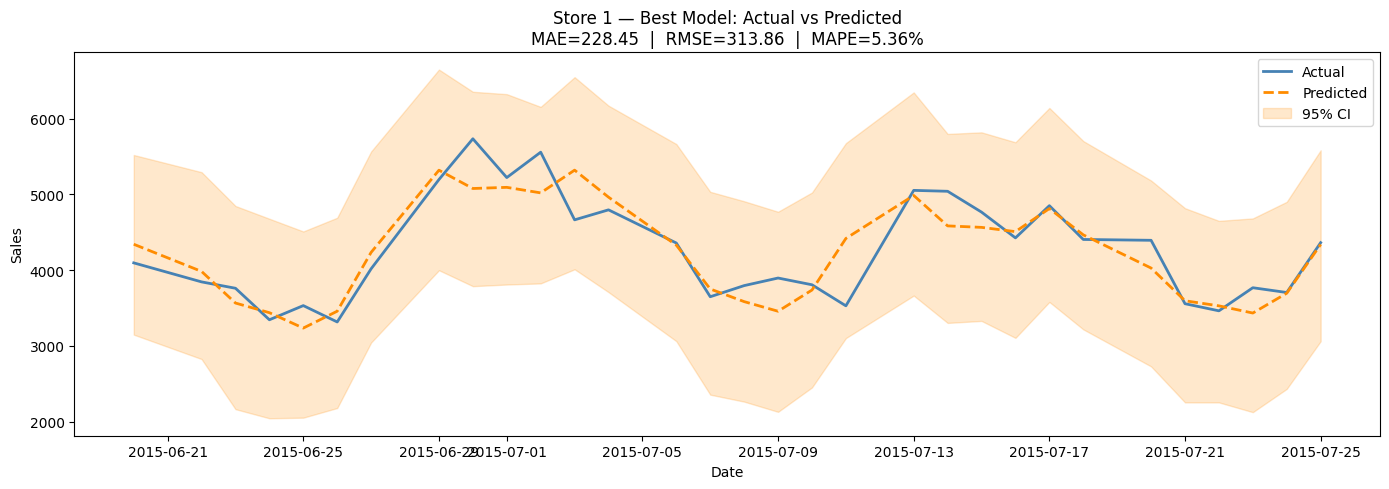

In [32]:
pred_val = forecast_optuna[forecast_optuna['ds'].isin(val_df['ds'])][
    ['ds','yhat','yhat_lower','yhat_upper']]
merged = val_df[['ds','y']].merge(pred_val, on='ds')
final_metrics = evaluate(merged['y'].values, merged['yhat'].values)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(merged['ds'], merged['y'],    label='Actual',     color='steelblue', linewidth=2)
ax.plot(merged['ds'], merged['yhat'], label='Predicted',  color='darkorange', linestyle='--', linewidth=2)
ax.fill_between(merged['ds'], merged['yhat_lower'], merged['yhat_upper'],
                alpha=0.2, color='darkorange', label='95% CI')
ax.set_title(f"Store {STORE_ID} — Best Model: Actual vs Predicted\n"
             f"MAE={final_metrics['MAE']}  |  RMSE={final_metrics['RMSE']}  |  MAPE={final_metrics['MAPE%']}%")
ax.set_xlabel('Date'); ax.set_ylabel('Sales')
ax.legend(); plt.tight_layout(); plt.show()

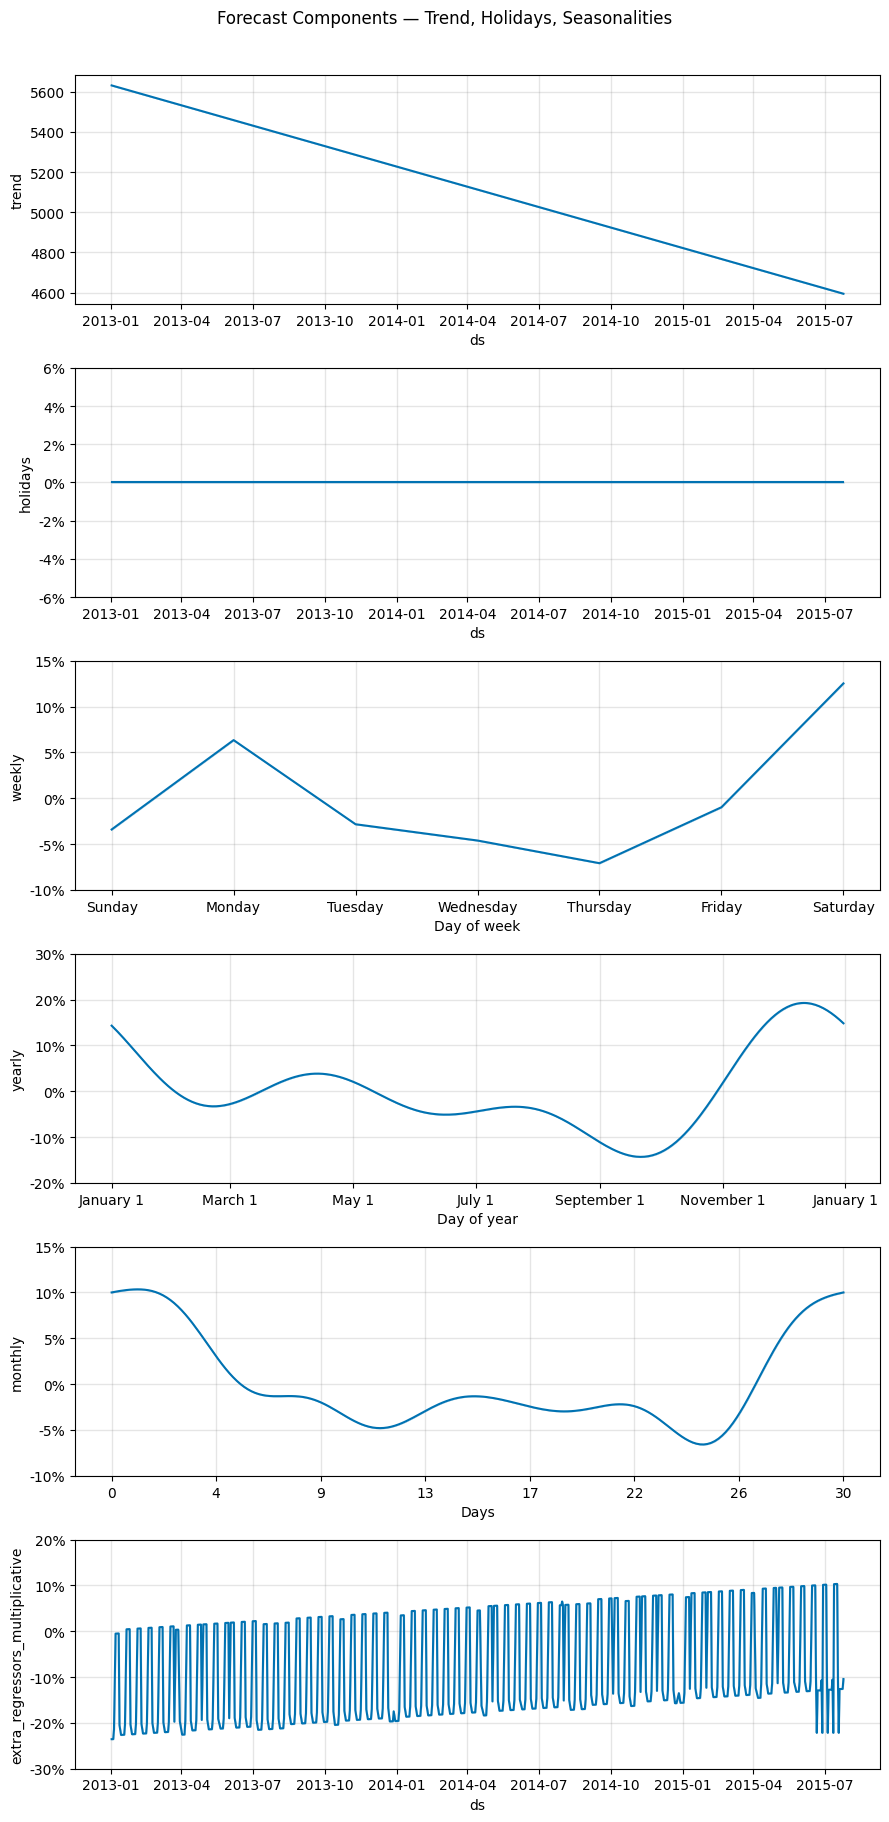

In [33]:
fig = best_model.plot_components(forecast_optuna)
plt.suptitle('Forecast Components — Trend, Holidays, Seasonalities', y=1.01)
plt.tight_layout()
plt.show()

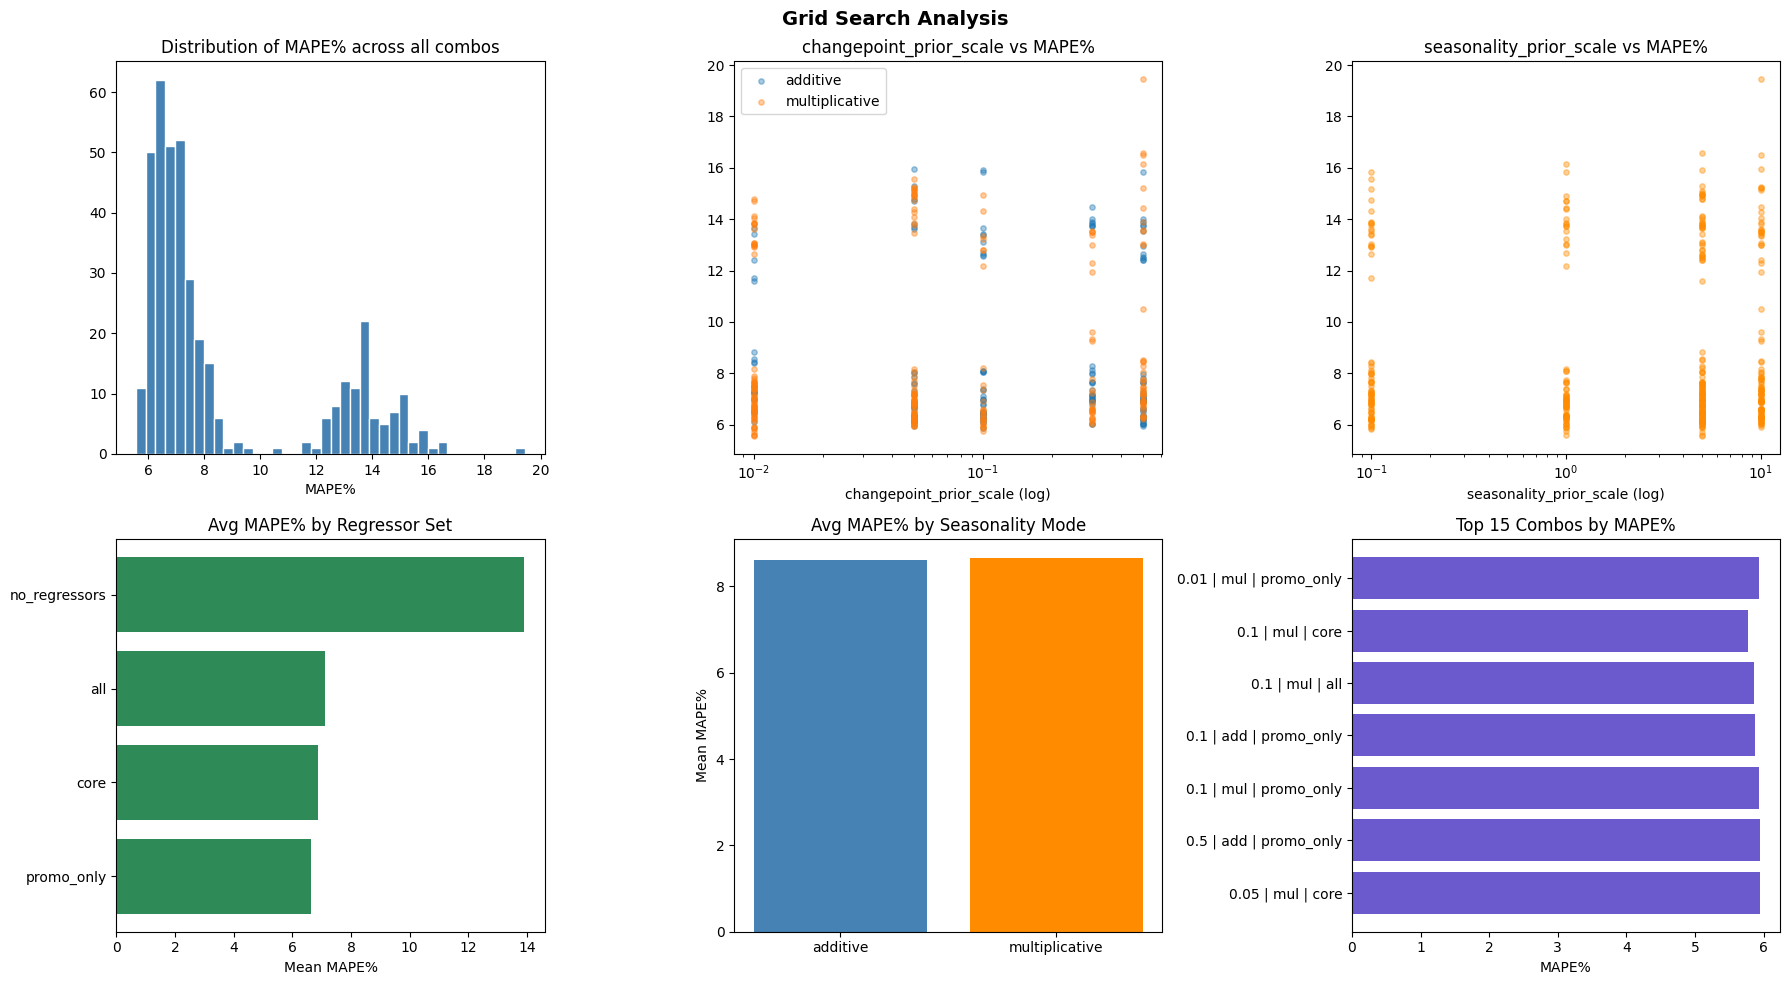

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distribution of MAPE
axes[0,0].hist(results_df['MAPE%'], bins=40, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribution of MAPE% across all combos')
axes[0,0].set_xlabel('MAPE%')

# 2. changepoint_prior_scale vs MAPE
for mode in ['additive','multiplicative']:
    subset = results_df[results_df['seasonality_mode'] == mode]
    axes[0,1].scatter(subset['changepoint_prior_scale'], subset['MAPE%'],
                      alpha=0.4, label=mode, s=15)
axes[0,1].set_xscale('log')
axes[0,1].set_title('changepoint_prior_scale vs MAPE%')
axes[0,1].set_xlabel('changepoint_prior_scale (log)')
axes[0,1].legend()

# 3. seasonality_prior_scale vs MAPE
axes[0,2].scatter(results_df['seasonality_prior_scale'], results_df['MAPE%'],
                  alpha=0.4, color='darkorange', s=15)
axes[0,2].set_xscale('log')
axes[0,2].set_title('seasonality_prior_scale vs MAPE%')
axes[0,2].set_xlabel('seasonality_prior_scale (log)')

# 4. Regressor set comparison
reg_perf = results_df.groupby('regressor_set')['MAPE%'].mean().sort_values()
axes[1,0].barh(reg_perf.index, reg_perf.values, color='seagreen')
axes[1,0].set_title('Avg MAPE% by Regressor Set')
axes[1,0].set_xlabel('Mean MAPE%')

# 5. Seasonality mode comparison
mode_perf = results_df.groupby('seasonality_mode')['MAPE%'].mean()
axes[1,1].bar(mode_perf.index, mode_perf.values, color=['steelblue','darkorange'])
axes[1,1].set_title('Avg MAPE% by Seasonality Mode')
axes[1,1].set_ylabel('Mean MAPE%')

# 6. Top 15 combinations
top15 = results_df.head(15).copy()
top15['label'] = (top15['changepoint_prior_scale'].round(3).astype(str) + ' | ' +
                  top15['seasonality_mode'].str[:3] + ' | ' +
                  top15['regressor_set'])
axes[1,2].barh(top15['label'], top15['MAPE%'], color='slateblue')
axes[1,2].invert_yaxis()
axes[1,2].set_title('Top 15 Combos by MAPE%')
axes[1,2].set_xlabel('MAPE%')

plt.suptitle('Grid Search Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

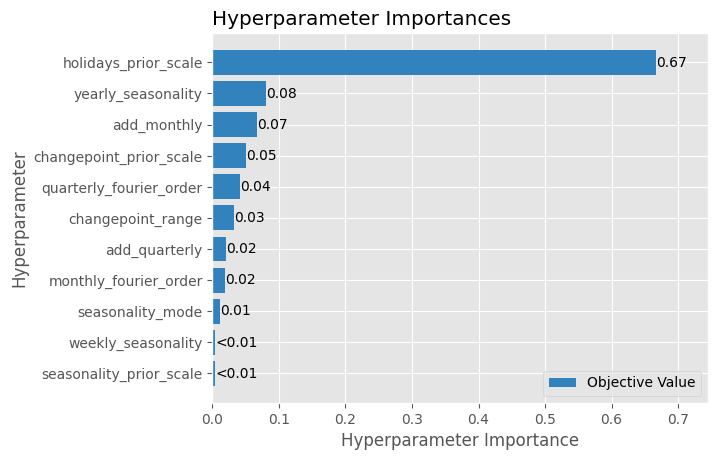

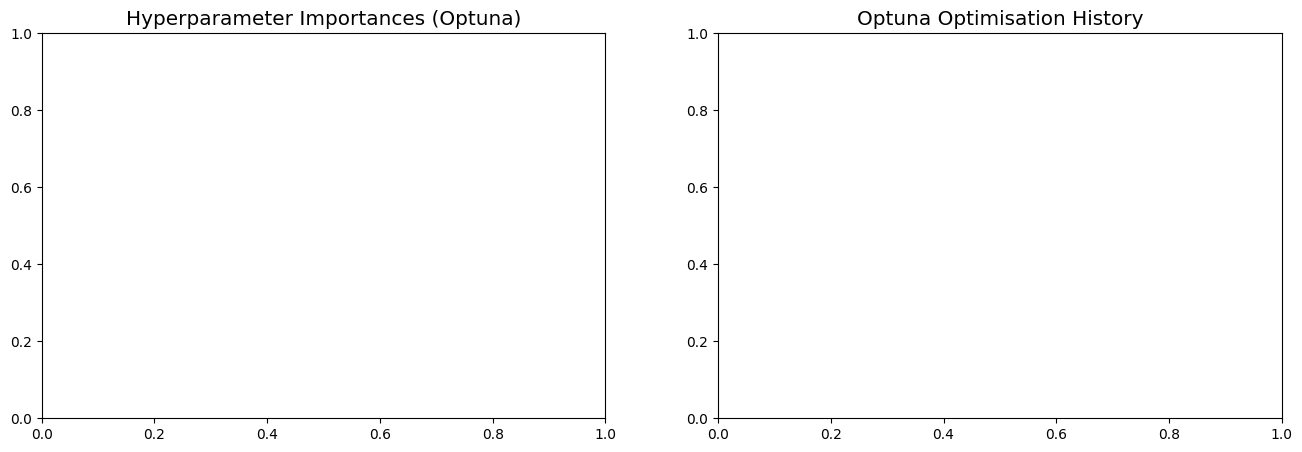

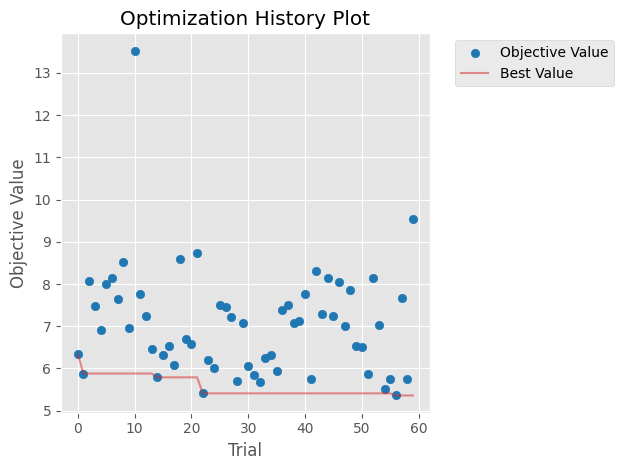

In [35]:
from optuna.visualization.matplotlib import (
    plot_param_importances,
    plot_optimization_history,
    plot_contour
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plt.sca(axes[0])
plot_param_importances(study)
axes[0].set_title('Hyperparameter Importances (Optuna)')

plt.sca(axes[1])
plot_optimization_history(study)
axes[1].set_title('Optuna Optimisation History')

plt.tight_layout()
plt.show()

          FINAL MODEL COMPARISON — Store 1

📌 PROPHET (Grid Search Best):
   changepoint_prior_scale             = 0.01
   seasonality_prior_scale             = 5.0
   holidays_prior_scale                = 1.0
   seasonality_mode                    = multiplicative
   regressor_set                       = promo_only
   MAPE%                               = 5.56

📌 PROPHET (Optuna Best — used as final model):
   changepoint_prior_scale             = 0.0013859633306681088
   seasonality_prior_scale             = 0.3637812274355575
   holidays_prior_scale                = 0.1880808019162299
   seasonality_mode                    = multiplicative
   changepoint_range                   = 0.945186478217238
   yearly_seasonality                  = 3
   weekly_seasonality                  = 5
   add_monthly                         = True
   monthly_fourier_order               = 6
   add_quarterly                       = False
   quarterly_fourier_order             = 5
   MAPE%                 

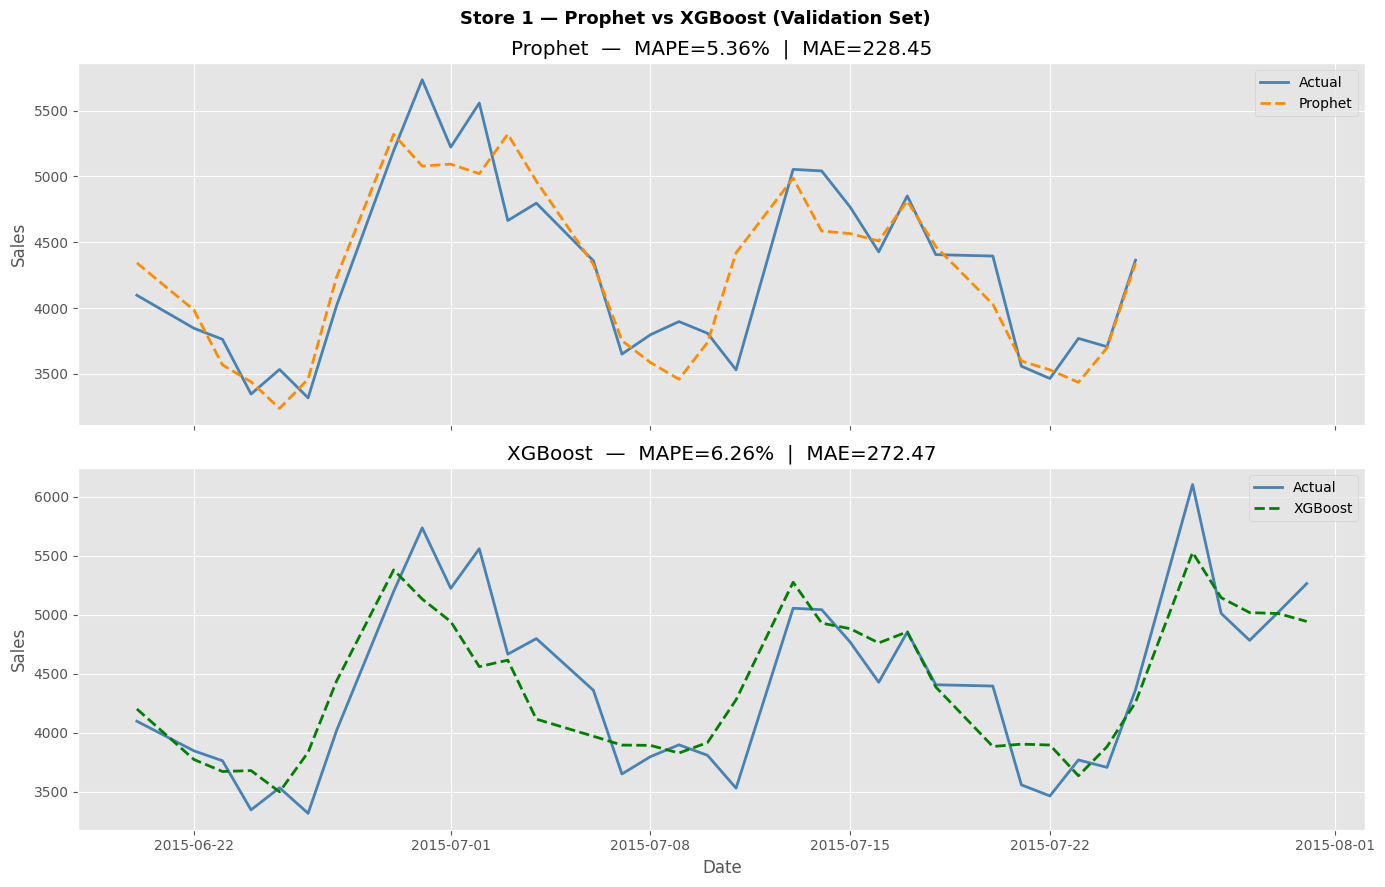


📌 Cross-Validation Comparison:

  Prophet CV (last 5 horizons):
horizon        mae        rmse     mape
38 days 814.158325 1133.314669 0.134452
39 days 874.588248 1218.819332 0.143115
40 days 850.860269 1206.217770 0.140791
41 days 954.946005 1319.614344 0.169088
42 days 871.271008 1208.274650 0.173739

  XGBoost Walk-Forward CV (all folds):
    cutoff     MAE    RMSE  MAPE%
2014-01-02 1239.75 1304.01  28.70
2014-04-02  541.95  723.55  10.27
2014-07-01  369.90  471.83   8.30
2014-09-29  399.40  574.97   8.21
2014-12-28  613.40  803.75  13.96
2015-03-28  574.32  709.01  11.96

  XGBoost CV Mean MAPE : 13.57%
  Prophet CV Mean MAPE : 11.44%


In [36]:
# ══════════════════════════════════════════════════════════════════
#  FINAL COMPARISON: Prophet vs XGBoost
# ══════════════════════════════════════════════════════════════════

print("=" * 68)
print("          FINAL MODEL COMPARISON — Store", STORE_ID)
print("=" * 68)

print("\n📌 PROPHET (Grid Search Best):")
for k in ['changepoint_prior_scale','seasonality_prior_scale',
          'holidays_prior_scale','seasonality_mode','regressor_set']:
    print(f"   {k:35s} = {best_grid.get(k,'—')}")
print(f"   {'MAPE%':35s} = {best_grid['MAPE%']}")

print("\n📌 PROPHET (Optuna Best — used as final model):")
for k, v in study.best_params.items():
    print(f"   {k:35s} = {v}")
print(f"   {'MAPE%':35s} = {study.best_value:.2f}%")

print("\n📌 XGBOOST (Optuna Best):")
for k, v in xgb_study.best_params.items():
    print(f"   {k:25s} = {v}")
print(f"   {'MAPE%':25s} = {xgb_study.best_value:.2f}%")

print("\n" + "─" * 68)
print(f"{'Model':<30} {'MAE':>10} {'RMSE':>10} {'MAPE%':>10}")
print("─" * 68)
print(f"{'Prophet (Optuna)':<30} {final_metrics['MAE']:>10} {final_metrics['RMSE']:>10} {final_metrics['MAPE%']:>10}")
print(f"{'XGBoost (Optuna)':<30} {xgb_metrics['MAE']:>10} {xgb_metrics['RMSE']:>10} {xgb_metrics['MAPE%']:>10}")
print("─" * 68)

# ── Side-by-side plot ─────────────────────────────────────────────
pred_prophet = forecast_optuna[forecast_optuna['ds'].isin(val_df['ds'])][['ds','yhat']]
pred_prophet = val_df[['ds','y']].merge(pred_prophet, on='ds')

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Prophet
axes[0].plot(pred_prophet['ds'], pred_prophet['y'],    color='steelblue',  label='Actual',  linewidth=2)
axes[0].plot(pred_prophet['ds'], pred_prophet['yhat'], color='darkorange', label='Prophet', linewidth=2, linestyle='--')
axes[0].set_title(f"Prophet  —  MAPE={final_metrics['MAPE%']}%  |  MAE={final_metrics['MAE']}")
axes[0].legend(); axes[0].set_ylabel('Sales')

# XGBoost
axes[1].plot(xgb_val['Date'], y_val.values, color='steelblue', label='Actual',  linewidth=2)
axes[1].plot(xgb_val['Date'], xgb_preds,    color='green',     label='XGBoost', linewidth=2, linestyle='--')
axes[1].set_title(f"XGBoost  —  MAPE={xgb_metrics['MAPE%']}%  |  MAE={xgb_metrics['MAE']}")
axes[1].legend(); axes[1].set_ylabel('Sales'); axes[1].set_xlabel('Date')

plt.suptitle(f'Store {STORE_ID} — Prophet vs XGBoost (Validation Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── CV comparison ─────────────────────────────────────────────────
print("\n📌 Cross-Validation Comparison:")
print(f"\n  Prophet CV (last 5 horizons):")
print(df_perf[['horizon','mae','rmse','mape']].tail(5).to_string(index=False))
print(f"\n  XGBoost Walk-Forward CV (all folds):")
print(xgb_cv_df[['cutoff','MAE','RMSE','MAPE%']].to_string(index=False))
print(f"\n  XGBoost CV Mean MAPE : {xgb_cv_df['MAPE%'].mean():.2f}%")
print(f"  Prophet CV Mean MAPE : {df_perf['mape'].mean()*100:.2f}%")
print("=" * 68)